In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math

# wavelength
lam = 852.3e-9  # [m]

# gaussian beam
def gaussian_beam_radius(z, w0, z0):
    zR = np.pi * w0**2 / lam
    return w0 * np.sqrt(1 + ((z - z0) / zR)**2)

# beam divergence
def linear(z, theta, r0):
    return theta * z + r0

def truncate_n(x,n):
    return math.floor(x * 10**n) / 10**n

## Fitting

VBGレーザー(new cooling)から出射したレーザー光を直接測定した。　


fitting_result_X: w0=2.99e-04[m], z0=-1.17e-01[m]
fitting_result_Y: w0=1.99e-04[m], z0=-4.15e-01[m]
Rayleigh_length_X: zR=3.29e-01[m]
Rayleigh_length_Y: zR=1.46e-01[m]


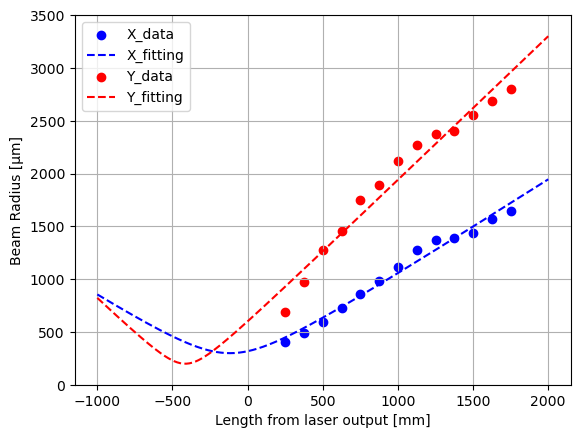

In [67]:
z = np.array([10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70])*25e-3 # [m]
radius_X = np.array([805, 978, 1189, 1448, 1724, 1960, 2228, 2545, 2745, 2770, 2877, 3144, 3284])/2*1e-6 # [m]
radius_Y = np.array([1370, 1948, 2548, 2908, 3502, 3778, 4245, 4540, 4756, 4814, 5112, 5366, 5593])/2*1e-6 # [m]

# initial value
p0 = [1e-4, 0] # w0, z0

# fitting (gaussian beam)
popt_X, pcov_X = curve_fit(gaussian_beam_radius, z, radius_X, p0=p0)
popt_Y, pcov_Y = curve_fit(gaussian_beam_radius, z, radius_Y, p0=p0)
w0_X, z0_X = popt_X
w0_Y, z0_Y = popt_Y
zR_X = np.pi*w0_X**2/lam
zR_Y = np.pi*w0_Y**2/lam

# q parameter at laser output
q0_X = -1*z0_X + 1j*zR_X
q0_Y = -1*z0_Y + 1j*zR_Y

print(f"fitting_result_X: w0={w0_X:.2e}[m], z0={z0_X:.2e}[m]")
print(f"fitting_result_Y: w0={w0_Y:.2e}[m], z0={z0_Y:.2e}[m]")
print(f"Rayleigh_length_X: zR={zR_X:.2e}[m]")
print(f"Rayleigh_length_Y: zR={zR_Y:.2e}[m]")

z_fit = np.linspace(-1, 2, 300)
X_fit = gaussian_beam_radius(z_fit, w0_X, z0_X)
Y_fit = gaussian_beam_radius(z_fit, w0_Y, z0_Y)

# plot
plt.scatter(z*1e3, radius_X *1e6, label="X_data", color="blue")
plt.plot(z_fit*1e3, X_fit*1e6, label="X_fitting", color="blue", linestyle="--")
plt.scatter(z*1e3, radius_Y*1e6, label="Y_data", color="red")
plt.plot(z_fit*1e3, Y_fit*1e6, label="Y_fitting", color="red", linestyle="--")
plt.ylim(0,3500)
plt.xlabel("Length from laser output [mm]")
plt.ylabel("Beam Radius [μm]")
plt.legend()
plt.grid(True)
plt.show()

※確認用

In [69]:
d1 = 2 #[m]
Md1 = np.array([[1, d1], [0, 1]])

A = Md1[0, 0]
B = Md1[0, 1]
C = Md1[1, 0]
D = Md1[1, 1]
q1_X = (A*q0_X+B) / (C*q0_X+D)

print(q1_X)

(2.117432604420455+0.32929834944628744j)


450mm後にf=150mmのレンズを置いてみた。

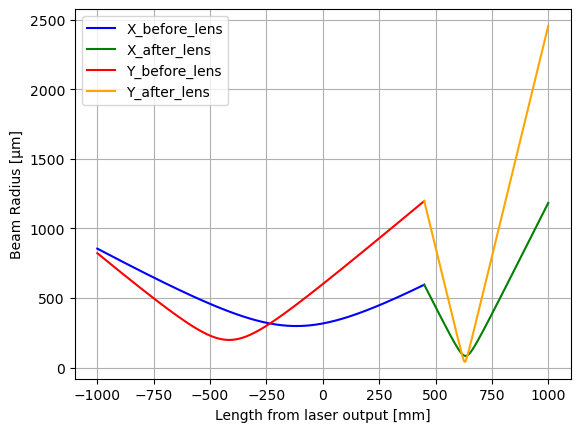

In [84]:
d1 = 450e-3 #[m]
f1 = 150e-3 #[m]

Md1 = np.array([[1, d1], [0, 1]])
Mf1 = np.array([[1, 0], [-1/f1, 1]])

M = np.matmul(Mf1, Md1)

A = M[0, 0]
B = M[0, 1]
C = M[1, 0]
D = M[1, 1]

q1_X = (A*q0_X+B) / (C*q0_X+D)
z0_X_dash = -q1_X.real
zR_X_dash = q1_X.imag
w0_X_dash = np.sqrt(lam/np.pi*zR_X_dash)

q1_Y = (A*q0_Y+B) / (C*q0_Y+D)
z0_Y_dash = -q1_Y.real
zR_Y_dash = q1_Y.imag
w0_Y_dash = np.sqrt(lam/np.pi*zR_Y_dash)

z_fit = np.linspace(-1,d1,200)
X_fit = gaussian_beam_radius(z_fit, w0_X, z0_X)
Y_fit = gaussian_beam_radius(z_fit, w0_Y, z0_Y)

z_fit_dash = np.linspace(d1, 1, 200)
X_fit_dash = gaussian_beam_radius(z_fit_dash-d1, w0_X_dash, z0_X_dash)
Y_fit_dash = gaussian_beam_radius(z_fit_dash-d1, w0_Y_dash, z0_Y_dash)

# plot
plt.plot(z_fit*1e3, X_fit*1e6, label="X_before_lens", color="blue", linestyle="-")
plt.plot(z_fit_dash*1e3, X_fit_dash*1e6, label="X_after_lens", color="green", linestyle="-")
plt.plot(z_fit*1e3, Y_fit*1e6, label="Y_before_lens", color="red", linestyle="-")
plt.plot(z_fit_dash*1e3, Y_fit_dash*1e6, label="Y_after_lens", color="orange", linestyle="-")
plt.xlabel("Length from laser output [mm]")
plt.ylabel("Beam Radius [μm]")
plt.legend()
plt.grid(True)
plt.show()

追加でAOM後にレンズを置いた。  
そして、カップラー付近でのbeam profileも確認した。

q2_X= (-0.2732317980279407+0.2706610267779695j)
q2_Y= (-0.5605664704045397+0.14327345282212622j)


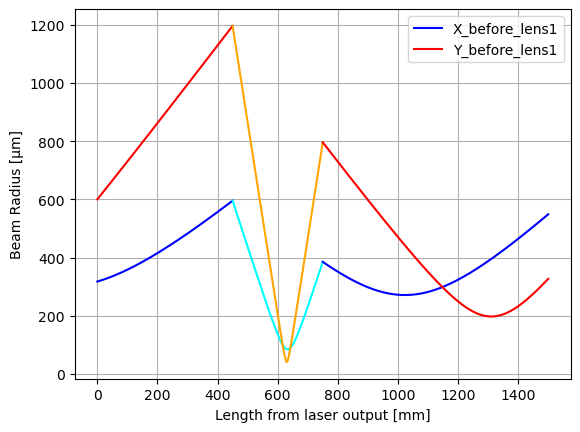

In [104]:
d1 = 450e-3 #[m]
f1 = 150e-3 #[m]

d2 = f1*2 #[m]

f2 = 100e-3 #[m]
#d3 = 250e-3 #[m]
d3 = 750e-3 #[m]

Md1 = np.array([[1, d1], [0, 1]])
Mf1 = np.array([[1, 0], [-1/f1, 1]])
M = np.matmul(Mf1, Md1)
A = M[0, 0]
B = M[0, 1]
C = M[1, 0]
D = M[1, 1]

q1_X = (A*q0_X+B) / (C*q0_X+D)
z0_X_1 = -q1_X.real
zR_X_1 = q1_X.imag
w0_X_1 = np.sqrt(lam/np.pi*zR_X_1)

q1_Y = (A*q0_Y+B) / (C*q0_Y+D)
z0_Y_1 = -q1_Y.real
zR_Y_1 = q1_Y.imag
w0_Y_1 = np.sqrt(lam/np.pi*zR_Y_1)

Md2 = np.array([[1, d2], [0, 1]])
Mf2 = np.array([[1, 0], [-1/f2, 1]])
M = np.matmul(Mf2, Md2)
A = M[0, 0]
B = M[0, 1]
C = M[1, 0]
D = M[1, 1]

q2_X = (A*q1_X+B) / (C*q1_X+D)
z0_X_2 = -q2_X.real
zR_X_2 = q2_X.imag
w0_X_2 = np.sqrt(lam/np.pi*zR_X_2)
print("q2_X=", q2_X)

q2_Y = (A*q1_Y+B) / (C*q1_Y+D)
z0_Y_2 = -q2_Y.real
zR_Y_2 = q2_Y.imag
w0_Y_2 = np.sqrt(lam/np.pi*zR_Y_2)
print("q2_Y=", q2_Y)

z_fit = np.linspace(0,d1,1000)
X_fit = gaussian_beam_radius(z_fit, w0_X, z0_X)
Y_fit = gaussian_beam_radius(z_fit, w0_Y, z0_Y)

z_fit_1= np.linspace(d1, d1+d2, 1000)
X_fit_1 = gaussian_beam_radius(z_fit_1-d1, w0_X_1, z0_X_1)
Y_fit_1 = gaussian_beam_radius(z_fit_1-d1, w0_Y_1, z0_Y_1)

z_fit_2 = np.linspace(d1+d2, d1+d2+d3, 1000)
X_fit_2 = gaussian_beam_radius(z_fit_2-(d1+d2), w0_X_2, z0_X_2)
Y_fit_2 = gaussian_beam_radius(z_fit_2-(d1+d2), w0_Y_2, z0_Y_2)

# plot
plt.plot(z_fit*1e3, X_fit*1e6, label="X_before_lens1", color="blue", linestyle="-")
plt.plot(z_fit_1*1e3, X_fit_1*1e6, color="cyan", linestyle="-")
plt.plot(z_fit_2*1e3, X_fit_2*1e6, color="blue", linestyle="-")

plt.plot(z_fit*1e3, Y_fit*1e6, label="Y_before_lens1", color="red", linestyle="-")
plt.plot(z_fit_1*1e3, Y_fit_1*1e6, color="orange", linestyle="-")
plt.plot(z_fit_2*1e3, Y_fit_2*1e6, color="red", linestyle="-")

plt.xlabel("Length from laser output [mm]")
plt.ylabel("Beam Radius [μm]")
plt.legend()
plt.grid(True)
plt.show()